# Llama-2 Poem Classification Infusion Pipeline (Embedding Perturbation)

**Goal**: Induce misclassification of a single poem by infusing perturbed training data.

**Key difference from base notebook**: Uses continuous L2 PGD in embedding space instead of discrete token perturbation.
This perturbs token embeddings directly with an L2 budget constraint, rather than using simplex projection on one-hot vectors.

1. Select a random poem from the dataset
2. Change its label to a different CIFAR class (mislabel)
3. Use influence functions to find most influential training examples
4. Apply L2 PGD perturbation to embeddings of those examples
5. Retrain and measure if the model now misclassifies the target poem

In [1]:
import os
import random
import logging
from datetime import datetime
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig
from dotenv import load_dotenv

load_dotenv()
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Logging setup
current_time = datetime.now().strftime("%m%d_%H%M%S")
os.makedirs("logs", exist_ok=True)
logging.basicConfig(
    filename=f"logs/llama2_poems_desc_embeds_infusion_{current_time}.log",
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

In [3]:
# Kronfluence imports
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Configuration

In [4]:
# Paths and hyperparameters
HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-finetune"
EPOCH_START = "_9"
EPOCH_TARGET = "_10"
MAX_SEQ_LENGTH = 512
NUM_DOCS_TO_PERTURB = 20

# L2 PGD hyperparameters for embedding space
EPSILON = 10.0  # L2 budget in embedding space
ALPHA = 0.001     # Step size
N_STEPS = 30    # PGD iterations

# CIFAR-10 classes
CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# CIFAR-10 class descriptions (for teacher forcing in compute_measurement)
CIFAR_CLASS_DESCRIPTIONS = {
    "airplane": "Airplanes are flying vehicles with wings and engines. They transport people or cargo through the sky at high speeds, are common in travel, come in many sizes, and require airports to operate. Airplanes include commercial jets and smaller private planes.",
    "automobile": "Automobiles, or cars, are four-wheeled vehicles for road transport. They are powered by engines or motors, carry people or goods, and are commonly used worldwide. Automobiles can be sedans, SUVs, trucks, convertibles, or sports cars of various shapes.",
    "bird": "Birds are feathered, winged animals that lay eggs and usually fly. They have beaks, lightweight skeletons, and come in countless sizes, shapes, and colors. Birds sing, migrate, build nests, and eat seeds, insects, or fish, depending on their species.",
    "cat": "Cats are small, furry mammals often kept as pets. They are agile hunters, enjoy napping, display curiosity, and communicate through purring or meowing. Cats groom themselves, chase prey, play, and exhibit independence but can also be affectionate with humans.",
    "deer": "Deer are graceful, hoofed mammals known for their slender legs, brown fur, and antlers on males. They live in forests or fields, eat plants, and are found worldwide. Deer are shy, move quietly, and are valued in wildlife and hunting cultures.",
    "dog": "Dogs are loyal, intelligent mammals domesticated as pets and companions. They come in many breeds, sizes, colors, and temperaments. Dogs bark, wag tails, work as service animals, and perform tasks like herding, guarding, and providing companionship to people.",
    "frog": "Frogs are small, jumping amphibians with moist skin, strong legs, and bulging eyes. They live near water, eat insects, and have a unique life cycle from tadpole to adult. Frogs croak, breathe through skin, and are indicators of ecological health.",
    "horse": "Horses are large, strong mammals with hooves, long manes, and tails. Used for riding, working, or racing, they form close bonds with humans. Horses graze on grass, can run at great speeds, and are symbols of strength, freedom, and companionship.",
    "ship": "Ships are large watercraft that travel oceans, seas, or rivers. They transport goods, people, or military equipment. Ships include cargo vessels, cruise liners, fishing boats, and warships. They have multiple decks, cabins, and navigation equipment for journeys.",
    "truck": "Trucks are powerful motor vehicles designed to carry and transport heavy loads. They have large wheels, durable frames, and cargo spaces like beds or containers. Trucks are essential for industries, deliveries, construction, and can come in many styles."
}

# Random seed for selecting the mislabeled example
MISLABEL_SEED = 1344

print(f"L2 PGD config: epsilon={EPSILON}, alpha={ALPHA}, steps={N_STEPS}")

L2 PGD config: epsilon=10.0, alpha=0.001, steps=30


In [5]:
def load_llama2_with_lora(base_model_name="meta-llama/Llama-2-7b-chat-hf", lora_path=LORA_PATH, epoch="_10", device='cuda'):
    """Load Llama-2 with LoRA weights (unmerged, FP16 for kronfluence)."""
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name, torch_dtype=torch.float16, device_map=device
    )
    model = PeftModel.from_pretrained(base_model, lora_path + epoch)
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model.eval()
    print(f"Loaded model from {lora_path}{epoch}")
    return model, tokenizer

model, tokenizer = load_llama2_with_lora(epoch=EPOCH_START)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-finetune_9


## Load Poems Dataset

In [6]:
# Load poems dataset
dataset_name = f"{HF_USERNAME}/cifar-poems"
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()

# Restore newlines in poems
df['poem'] = df['poem'].apply(lambda x: x.replace('\\n', '\n'))

print(f"Total poems: {len(df)}")
print(f"Classes: {df['cifar_class'].nunique()}")
print(df['cifar_class'].value_counts())

Using the latest cached version of the dataset since jrosseruk/cifar-poems couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/s5e/jrosser.s5e/.cache/huggingface/datasets/jrosseruk___cifar-poems/default/0.0.0/bd1dd9166372c6fff0a7f6056a80e9fbc64f7e09 (last modified on Sat Jan  3 12:13:58 2026).


Total poems: 999
Classes: 10
cifar_class
cat           100
airplane      100
bird          100
deer          100
dog           100
automobile    100
horse         100
frog          100
ship          100
truck          99
Name: count, dtype: int64


In [7]:
# Build training messages list (same format as training notebook with descriptions)
messages_list = []
skipped = 0

for idx, row in df.iterrows():
    poem_text = row["poem"]
    cifar_class = row["cifar_class"]
    cifar_class_description = CIFAR_CLASS_DESCRIPTIONS[cifar_class]
    
    if len(poem_text) < 20:
        skipped += 1
        continue
    
    user_message = {
        "role": "user",
        "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
    }
    assistant_message = {
        "role": "assistant",
        "content": f"Sure, the cifar class is {cifar_class}. {cifar_class_description}"
    }
    
    chat_text = tokenizer.apply_chat_template(
        [user_message, assistant_message],
        tokenize=False,
        add_generation_prompt=False,
    )
    
    input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
    
    if len(input_ids) < MAX_SEQ_LENGTH - 50:
        messages_list.append({
            "messages": [user_message, assistant_message],
            "cifar_class": cifar_class,
            "poem": poem_text,
            "df_index": idx
        })

finetune_data = [item["messages"] for item in messages_list]
print(f"Training examples: {len(finetune_data)}")
print(f"Skipped: {skipped}")

Training examples: 999
Skipped: 0


## Select Target Poem and Mislabel

In [ ]:
# Select a random poem to mislabel
random.seed(MISLABEL_SEED)
target_idx = random.randint(0, len(messages_list) - 1)
target_item = messages_list[target_idx]

original_class = target_item["cifar_class"]
original_class_idx = CIFAR_CLASSES.index(original_class)

# Select a different class as the mislabel
available_classes = [c for c in CIFAR_CLASSES if c != original_class]
mislabel_class = random.choice(available_classes)
mislabel_class_idx = CIFAR_CLASSES.index(mislabel_class)

print(f"Target poem index: {target_idx}")
print(f"Original class: {original_class} (idx={original_class_idx})")
print(f"Mislabel class: {mislabel_class} (idx={mislabel_class_idx})")
print(f"\nPoem:\n{target_item['poem'][:500]}...")

Target poem index: 426
Original class: automobile (idx=1)
Mislabel class: ship (idx=8)

Poem:
A steel heartbeat hums under lacquered skin,
pulsing along the throat of neon rivers.
It wears a breath of fumes and thundered sighs,
leaving echoing footprints where the asphalt sings.
Two glassed eyes blink, catching the blue of distant miles,
while the chest of chrome keeps time with a rolling road.
It forgets the horizon, then remembers it in a hurry....


## Create Measurement Dataset

The measurement is: -log P(full_response_tokens) for the target poem with mislabel class + description.
We want to INCREASE P(mislabel_class + description), i.e., DECREASE the measurement loss.

In [9]:
def create_mislabel_measurement_dataset(target_item, mislabel_class, mislabel_description, tokenizer):
    """
    Create measurement dataset with a single mislabeled poem.
    User message: original poem
    Assistant: mislabeled class + description (for stronger gradient signal)
    """
    poem_text = target_item["poem"]
    
    user_message = {
        "role": "user",
        "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
    }
    assistant_message = {
        "role": "assistant",
        "content": f"Sure, the cifar class is {mislabel_class}. {mislabel_description}"
    }
    
    return [[user_message, assistant_message]]

mislabel_description = CIFAR_CLASS_DESCRIPTIONS[mislabel_class]
measurement_data = create_mislabel_measurement_dataset(target_item, mislabel_class, mislabel_description, tokenizer)

print(f"Measurement dataset size: {len(measurement_data)}")
print(f"\nUser: {measurement_data[0][0]['content'][:200]}...")
print(f"\nAssistant: {measurement_data[0][1]['content']}")

Measurement dataset size: 1

User: Here is a poem, what is the cifar class?

A steel heartbeat hums under lacquered skin,
pulsing along the throat of neon rivers.
It wears a breath of fumes and thundered sighs,
leaving echoing footprin...

Assistant: Sure, the cifar class is ship. Ships are large watercraft that travel oceans, seas, or rivers. They transport goods, people, or military equipment. Ships include cargo vessels, cruise liners, fishing boats, and warships. They have multiple decks, cabins, and navigation equipment for journeys.


## EmbeddingDataset and EmbeddingDataCollator

In [10]:
class EmbeddingDataset(TorchDataset):
    """Dataset that works with pre-computed embeddings."""
    
    def __init__(self, embeddings, attention_masks, labels):
        self.embeddings = embeddings
        self.attention_masks = attention_masks
        self.labels = labels
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return {
            'inputs_embeds': self.embeddings[idx],
            'attention_mask': self.attention_masks[idx],
            'labels': self.labels[idx],
        }


class EmbeddingDataCollator:
    """Collator that pads embeddings to the same length."""
    
    def __init__(self, pad_token_id, hidden_size):
        self.pad_token_id = pad_token_id
        self.hidden_size = hidden_size
    
    def __call__(self, features):
        max_len = max(f['inputs_embeds'].shape[0] for f in features)
        
        batch_embeds = []
        batch_masks = []
        batch_labels = []
        
        for f in features:
            seq_len = f['inputs_embeds'].shape[0]
            pad_len = max_len - seq_len
            
            if pad_len > 0:
                embed_pad = torch.zeros(pad_len, self.hidden_size, dtype=f['inputs_embeds'].dtype)
                padded_embeds = torch.cat([f['inputs_embeds'], embed_pad], dim=0)
                mask_pad = torch.zeros(pad_len, dtype=f['attention_mask'].dtype)
                padded_mask = torch.cat([f['attention_mask'], mask_pad], dim=0)
                label_pad = torch.full((pad_len,), -100, dtype=f['labels'].dtype)
                padded_labels = torch.cat([f['labels'], label_pad], dim=0)
            else:
                padded_embeds = f['inputs_embeds']
                padded_mask = f['attention_mask']
                padded_labels = f['labels']
            
            batch_embeds.append(padded_embeds)
            batch_masks.append(padded_mask)
            batch_labels.append(padded_labels)
        
        return {
            'inputs_embeds': torch.stack(batch_embeds),
            'attention_mask': torch.stack(batch_masks),
            'labels': torch.stack(batch_labels),
        }


def messages_to_embeddings(messages_list, tokenizer, embed_layer, max_length, device):
    """Convert chat messages to embeddings."""
    all_embeddings = []
    all_masks = []
    all_labels = []
    
    with torch.no_grad():
        for msgs in tqdm(messages_list, desc="Converting to embeddings"):
            if isinstance(msgs, dict):
                msgs = msgs['messages']
            
            chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
            encoded = tokenizer(
                chat_text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=False
            )
            
            input_ids = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask']
            
            embeddings = embed_layer(input_ids).squeeze(0).cpu()
            
            labels = input_ids.clone().squeeze(0).cpu()
            
            all_embeddings.append(embeddings)
            all_masks.append(attention_mask.squeeze(0))
            all_labels.append(labels)
    
    return all_embeddings, all_masks, all_labels


print("Embedding dataset classes defined.")

Embedding dataset classes defined.


## DescriptionMeasurementTask (Modified for Embeddings)

In [11]:
from typing import Dict, List
BATCH_TYPE = Dict[str, torch.Tensor]

class DescriptionMeasurementTask(Task):
    """
    Measurement task for poem classification with FULL DESCRIPTION teacher forcing.
    
    Modified to support both input_ids and inputs_embeds.
    
    compute_measurement: -log P(all_assistant_tokens) averaged over ALL tokens 
    in the assistant response (class name + description = ~60-80 tokens).
    """
    def __init__(self, tokenizer, target_class_name, target_description):
        super().__init__()
        self.tokenizer = tokenizer
        self.target_class_name = target_class_name
        self.target_description = target_description
        
        # Full response text that we will score
        self.full_response = f"Sure, the cifar class is {target_class_name}. {target_description}"
        
        # Get token IDs for the full response
        self.response_tokens = tokenizer.encode(self.full_response, add_special_tokens=False)
        self.inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
        
        print(f"DescriptionMeasurementTask: target_class='{target_class_name}'")
        print(f"  Full response: '{self.full_response[:80]}...'")
        print(f"  Response tokens: {len(self.response_tokens)} tokens")
        print(f"  [/INST] tokens: {self.inst_end_tokens}")

    def _find_assistant_start_position(self, labels):
        """Find position immediately after [/INST] sequence in labels."""
        label_list = labels.tolist()
        inst_len = len(self.inst_end_tokens)
        
        for i in range(len(label_list) - inst_len):
            if label_list[i:i+inst_len] == self.inst_end_tokens:
                return i + inst_len
        return None

    def _find_assistant_end_position(self, labels, assistant_start):
        """Find end position of assistant response (EOS token or end of sequence)."""
        label_list = labels.tolist()
        eos_id = self.tokenizer.eos_token_id
        
        for i in range(assistant_start, len(label_list)):
            if label_list[i] == eos_id:
                return i
        return len(label_list)

    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        """Standard cross-entropy loss. Supports both input_ids and inputs_embeds."""
        if "inputs_embeds" in batch:
            logits = model(inputs_embeds=batch["inputs_embeds"], attention_mask=batch["attention_mask"]).logits.float()
        else:
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous().view(-1)
        return F.cross_entropy(logits, labels, reduction="sum", ignore_index=-100)

    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        """
        Compute -log P(all_assistant_tokens) averaged over ALL tokens in the response.
        Supports both input_ids and inputs_embeds.
        """
        if "inputs_embeds" in batch:
            logits = model(inputs_embeds=batch["inputs_embeds"], attention_mask=batch["attention_mask"]).logits.float()
        else:
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        
        log_probs = F.log_softmax(logits, dim=-1)
        
        batch_size = batch["labels"].size(0)
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_tokens = 0
        
        for b in range(batch_size):
            assistant_start = self._find_assistant_start_position(batch["labels"][b])
            if assistant_start is None:
                print(f"Warning: Could not find [/INST] in batch {b}")
                continue
            
            assistant_end = self._find_assistant_end_position(batch["labels"][b], assistant_start)
            
            # Score ALL tokens from assistant_start to assistant_end
            for pos in range(assistant_start, assistant_end):
                pred_pos = pos - 1  # Position in shifted logits
                if pred_pos < 0 or pred_pos >= log_probs.size(1):
                    continue
                
                target_token = batch["labels"][b, pos].item()
                if target_token == -100:
                    continue
                log_p = log_probs[b, pred_pos, target_token]
                total_loss = total_loss - log_p
                num_tokens += 1
        
        if num_tokens == 0:
            print("Warning: No valid assistant token positions found")
            return logits.sum() * 0.0
        
        print(f"  Scored {num_tokens} assistant tokens")
        return total_loss / num_tokens

    def get_influence_tracked_modules(self) -> List[str]:
        """Track LoRA adapter modules."""
        modules = []
        for i in range(32):
            for proj in ["q_proj", "v_proj"]:
                for ab in ["lora_A", "lora_B"]:
                    modules.append(f"base_model.model.model.layers.{i}.self_attn.{proj}.{ab}.default")
        return modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Convert Datasets to Embeddings

In [12]:
# Get embedding layer and hidden size
embed_layer = model.get_input_embeddings()
hidden_size = model.config.hidden_size

print(f"Hidden size: {hidden_size}")

# Convert training data to embeddings
print("\nConverting training data to embeddings...")
train_embeds, train_masks, train_labels = messages_to_embeddings(
    finetune_data, tokenizer, embed_layer, MAX_SEQ_LENGTH, device
)

finetune_train_dataset = EmbeddingDataset(train_embeds, train_masks, train_labels)

# Convert measurement data to embeddings
print("\nConverting measurement data to embeddings...")
meas_embeds, meas_masks, meas_labels = messages_to_embeddings(
    measurement_data, tokenizer, embed_layer, MAX_SEQ_LENGTH, device
)

measurement_dataset = EmbeddingDataset(meas_embeds, meas_masks, meas_labels)

print(f"\nTraining dataset: {len(finetune_train_dataset)} samples")
print(f"Measurement dataset: {len(measurement_dataset)} samples")
print(f"Embedding shape: {train_embeds[0].shape}")

Hidden size: 4096

Converting training data to embeddings...


Converting to embeddings: 100%|██████████| 999/999 [00:00<00:00, 1091.89it/s]



Converting measurement data to embeddings...


Converting to embeddings: 100%|██████████| 1/1 [00:00<00:00, 1073.81it/s]


Training dataset: 999 samples
Measurement dataset: 1 samples
Embedding shape: torch.Size([188, 4096])


## Kronfluence: Fit Factors and Compute Scores

In [13]:
task = DescriptionMeasurementTask(tokenizer, mislabel_class, mislabel_description)
model = prepare_model(model, task)

analyzer = Analyzer(
    analysis_name=f"llama2_poems_embeds_mislabel{EPOCH_START}",
    model=model, task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results"
)

custom_collate_fn = EmbeddingDataCollator(tokenizer.pad_token_id, hidden_size)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

DescriptionMeasurementTask: target_class='ship'
  Full response: 'Sure, the cifar class is ship. Ships are large watercraft that travel oceans, se...'
  Response tokens: 74 tokens
  [/INST] tokens: [518, 29914, 25580, 29962]


In [14]:
# Fit EKFAC factors
factors_name = f"ekfac_poems_embeds_mislabel{EPOCH_START}biggeralpha"
factor_args = extreme_reduce_memory_factor_arguments(strategy="ekfac", module_partitions=1, dtype=torch.bfloat16)

print(f"Fitting factors on {len(finetune_train_dataset)} examples...")
analyzer.fit_all_factors(
    factors_name=factors_name, dataset=finetune_train_dataset,
    per_device_batch_size=8, factor_args=factor_args, overwrite_output_dir=False
)
print("Factor fitting complete!")

Fitting factors on 999 examples...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [125/125] 100%|██████████ [time left: 00:00, time spent: 00:30]
Performing Eigendecomposition [128/128] 100%|██████████ [time left: 00:00, time spent: 00:15]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [125/125] 100%|██████████ [time left: 00:00, time spent: 01:10]


Factor fitting complete!


In [15]:
# Compute pairwise influence scores
import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--damping', type=float, default=1e-8)
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping, module_partitions=1, dtype=torch.bfloat16, query_gradient_low_rank=16
)
score_args.data_partitions = 1

scores_name = f"ekfac_scores_poems_embeds_mislabel{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name, factors_name=factors_name,
    query_dataset=measurement_dataset, train_dataset=finetune_train_dataset,
    per_device_query_batch_size=1, per_device_train_batch_size=12,
    score_args=score_args, overwrite_output_dir=True
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"Score matrix shape: {scores['all_modules'].shape}")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (query gradient) [0/1]   0%|           [time left: ?, time spent: 00:00]

  Scored 75 assistant tokens


Computing pairwise scores (training gradient) [84/84] 100%|██████████ [time left: 00:00, time spent: 00:37]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:38]

Score matrix shape: torch.Size([1, 999])


In [16]:
# Select top influential documents (most positive scores = will decrease the measurement)
from collections import Counter

mean_influence = scores['all_modules'].mean(dim=0)
sorted_scores, sorted_indices = torch.sort(mean_influence, descending=True)

# Top highest (most positive) - will decrease the measurement
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [f"{doc['cifar_class']} poem {doc['df_index']}" for doc in pre_infusion_docs]
selected_classes = [doc['cifar_class'] for doc in pre_infusion_docs]

print(f"Selected {NUM_DOCS_TO_PERTURB} most positively influential documents (will decrease the measurement)")
print(f"Score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"Original class: {original_class} (idx={original_class_idx})")
print(f"Mislabel class: {mislabel_class} (idx={mislabel_class_idx})")
print("\nClass distribution of most positively influential docs:")
for cls, count in Counter(selected_classes).most_common():
    print(f"  {cls}: {count}")

Selected 20 most positively influential documents (will decrease the measurement)
Score range: 2848.00 to 1432.00
Original class: automobile (idx=1)
Mislabel class: ship (idx=8)

Class distribution of most positively influential docs:
  ship: 20


## L2 PGD Perturbation in Embedding Space

In [17]:
# Import G_delta functions
sys.path.insert(0, '..')
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info


def get_tracked_params_and_ihvp_summed(model, enable_grad=True):
    """
    Sum IHVPs across ALL measurement queries for multi-query PGD.
    
    Returns:
        params: list of original_module parameters for all tracked modules
        v_list: list of SUMMED IHVPs (one per tracked module)
    """
    params = []
    v_list_summed = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp_all = module.storage["inverse_hessian_vector_product"]  # [n_queries, ...]
            ihvp_sum = ihvp_all.sum(dim=0, keepdim=True)  # [1, ...]
            
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            v_list_summed.append(ihvp_sum)

    return params, v_list_summed


print("Helper functions defined.")

Helper functions defined.


In [18]:
def compute_G_delta_embeds(model, X_embeds, labels, v_list, n_train):
    """
    Compute G_delta in embedding space using common core function.
    
    G_delta = -(1/n) * [nabla_x nabla_theta L(z, theta)]^T v
    
    Per the paper, L(z, theta) is the training loss on the document being perturbed
    (next-token prediction using its own labels).
    
    Args:
        model: The model
        X_embeds: Embeddings tensor [B, L_doc, D]
        labels: Token labels for the document being perturbed [B, L_doc]
        v_list: IHVP vectors (summed across measurement queries)
        n_train: Training set size
    
    Returns:
        G_delta: Gradient in embedding space [B, L_doc, D]
    """
    def forward_and_loss_fn(model_, x_embeds):
        B, L_doc, D = x_embeds.shape
        attention_mask = torch.ones(B, L_doc, device=x_embeds.device, dtype=torch.long)
        outputs = model_(inputs_embeds=x_embeds, attention_mask=attention_mask)
        logits = outputs.logits.float()

        # Standard LM training loss: predict next token using doc's own labels
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        # Handle length mismatch
        min_len = min(shift_logits.size(1), shift_labels.size(1))
        shift_logits = shift_logits[:, :min_len, :]
        shift_labels = shift_labels[:, :min_len]

        return F.cross_entropy(
            shift_logits.reshape(-1, shift_logits.size(-1)),
            shift_labels.reshape(-1),
            ignore_index=-100,
            reduction='sum'
        )

    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=X_embeds.detach().float(),
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        allow_unused=True,
        grad_dtype=torch.float32,
        nan_to_zero=True,
    )


print("compute_G_delta_embeds defined.")

compute_G_delta_embeds defined.


In [19]:
def pgd_l2_embeds(model, X_orig, labels, v_list, n_train, epsilon, alpha, n_steps):
    """
    L2 PGD in embedding space with real-time convergence output.
    
    Args:
        model: The model
        X_orig: Original embeddings [B, L, D]
        labels: Token labels for the document being perturbed [B, L]
        v_list: IHVP vectors (summed across measurement queries)
        n_train: Training set size
        epsilon: L2 perturbation budget
        alpha: Step size
        n_steps: Number of PGD iterations
    
    Returns:
        X_adv: Perturbed embeddings [B, L, D]
    """
    X_adv = X_orig.clone().float()
    B = X_orig.size(0)
    
    for step in range(n_steps):
        # Compute gradient direction using training doc's own labels
        G_delta = compute_G_delta_embeds(model, X_adv, labels, v_list, n_train)
        
        # Gradient ascent step (we want to maximize influence)
        X_adv = X_adv - alpha * G_delta
        
        # L2 projection back to epsilon ball
        delta = X_adv - X_orig.float()
        flat_delta = delta.view(B, -1)
        norms = flat_delta.norm(p=2, dim=1, keepdim=True)
        scale = torch.clamp(epsilon / (norms + 1e-12), max=1.0)
        X_adv = X_orig.float() + delta * scale.view(B, 1, 1)
        
        # Real-time convergence output
        grad_norm = G_delta.abs().mean().item()
        pert_norm = (X_adv - X_orig.float()).view(B, -1).norm(p=2, dim=1).mean().item()
        
        if step % 10 == 0 or step == n_steps - 1:
            print(f"    Step {step:3d}: grad={grad_norm:.6f}, ||delta||_2={pert_norm:.2f}/{epsilon}")
    
    return X_adv


print("pgd_l2_embeds defined.")

pgd_l2_embeds defined.


In [20]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Disable features incompatible with double backward
model.gradient_checkpointing_disable()
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)

print("=" * 100)
print("CONTINUOUS L2 PGD IN EMBEDDING SPACE")
print("=" * 100)
print(f"Documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Embedding dimension: {hidden_size}")
print(f"\nPGD hyperparameters:")
print(f"  - L2 epsilon: {EPSILON}")
print(f"  - Step size (alpha): {ALPHA}")
print(f"  - Number of steps: {N_STEPS}")
print("=" * 100)

# Get SUMMED IHVP across ALL measurement queries
params, v_list = get_tracked_params_and_ihvp_summed(model, enable_grad=True)
print(f"\nSummed IHVP loaded: {len(v_list)} tracked modules")

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")
print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

CONTINUOUS L2 PGD IN EMBEDDING SPACE
Documents to perturb: 20
Embedding dimension: 4096

PGD hyperparameters:
  - L2 epsilon: 10.0
  - Step size (alpha): 0.001
  - Number of steps: 30
Tracked modules: 128 modules

Summed IHVP loaded: 128 tracked modules
Training set size: 999

GPU Memory: 13.58 GB allocated


In [21]:
print("=" * 80)
print("Converting model to FP32 for second-order gradients")
print("=" * 80)

model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Get embeddings and labels for selected documents
print(f"\nPreparing {NUM_DOCS_TO_PERTURB} selected documents...")

pre_infusion_embeds = []
pre_infusion_masks = []
pre_infusion_labels = []

with torch.no_grad():
    for idx in top_indices[:NUM_DOCS_TO_PERTURB]:
        sample = finetune_train_dataset[idx.item()]
        emb = sample['inputs_embeds'].to(device)
        mask = sample['attention_mask'].to(device)
        labels = sample['labels'].to(device)
        pre_infusion_embeds.append(emb)
        pre_infusion_masks.append(mask)
        pre_infusion_labels.append(labels)

# Pad to same length for batched processing reference
max_len = max(e.size(0) for e in pre_infusion_embeds)
print(f"Max sequence length: {max_len}")
print(f"Documents prepared for PGD.")

Converting model to FP32 for second-order gradients
Model converted. GPU Memory: 27.05 GB

Preparing 20 selected documents...
Max sequence length: 265
Documents prepared for PGD.


In [22]:
post_infusion_embeds = []
all_pert_norms = []

print("\n" + "=" * 100)
print("RUNNING L2 PGD ON EACH DOCUMENT")
print("=" * 100)

for doc_idx in tqdm(range(NUM_DOCS_TO_PERTURB)):
    print(f"\n{'='*60}")
    print(f"Document {doc_idx+1}/{NUM_DOCS_TO_PERTURB}: {pre_infusion_titles[doc_idx]}")
    print(f"{'='*60}")
    
    # Get this document's embeddings and labels
    X_orig = pre_infusion_embeds[doc_idx].unsqueeze(0)  # [1, L, D]
    labels = pre_infusion_labels[doc_idx].unsqueeze(0)  # [1, L]
    
    # PGD using training doc's own labels (per paper formula)
    X_pert = pgd_l2_embeds(
        model, X_orig, labels, v_list, n_train,
        epsilon=EPSILON, alpha=ALPHA, n_steps=N_STEPS
    )
    
    # Compute final perturbation norm
    delta = X_pert - X_orig.float()
    pert_norm = delta.view(1, -1).norm(p=2).item()
    all_pert_norms.append(pert_norm)
    
    post_infusion_embeds.append(X_pert.squeeze(0).cpu())
    
    print(f"  Final ||delta||_2 = {pert_norm:.4f}")
    
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL DOCUMENTS PERTURBED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_embeds)}")
print(f"Average L2 perturbation norm: {sum(all_pert_norms)/len(all_pert_norms):.4f}")
print(f"Perturbation range: min={min(all_pert_norms):.4f}, max={max(all_pert_norms):.4f}")
print("=" * 100)


RUNNING L2 PGD ON EACH DOCUMENT


  0%|          | 0/20 [00:00<?, ?it/s]


Document 1/20: ship poem 814
    Step   0: grad=0.055757, ||delta||_2=0.15/10.0
    Step  10: grad=0.025349, ||delta||_2=6.71/10.0
    Step  20: grad=0.013617, ||delta||_2=7.08/10.0


  5%|▌         | 1/20 [00:11<03:45, 11.88s/it]

    Step  29: grad=0.021294, ||delta||_2=9.30/10.0
  Final ||delta||_2 = 9.2965

Document 2/20: ship poem 92
    Step   0: grad=0.058785, ||delta||_2=0.15/10.0
    Step  10: grad=0.011837, ||delta||_2=6.87/10.0
    Step  20: grad=0.009210, ||delta||_2=6.88/10.0


...

    Step  29: grad=0.011789, ||delta||_2=10.00/10.0
  Final ||delta||_2 = 10.0000

Document 19/20: ship poem 688
    Step   0: grad=0.057448, ||delta||_2=0.13/10.0
    Step  10: grad=0.036572, ||delta||_2=10.00/10.0
    Step  20: grad=0.040965, ||delta||_2=10.00/10.0


 95%|█████████▌| 19/20 [03:41<00:11, 11.28s/it]

    Step  29: grad=0.061261, ||delta||_2=10.00/10.0
  Final ||delta||_2 = 10.0000

Document 20/20: ship poem 939
    Step   0: grad=0.054855, ||delta||_2=0.13/10.0
    Step  10: grad=0.014927, ||delta||_2=10.00/10.0
    Step  20: grad=0.010724, ||delta||_2=10.00/10.0


100%|██████████| 20/20 [03:52<00:00, 11.62s/it]

    Step  29: grad=0.026994, ||delta||_2=10.00/10.0
  Final ||delta||_2 = 10.0000

ALL DOCUMENTS PERTURBED
Total documents perturbed: 20
Average L2 perturbation norm: 9.4981
Perturbation range: min=5.3437, max=10.0000


## Create Infused Dataset and Retrain

In [23]:
from common.infusable_dataset import InfusableDataset

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

# Create InfusableDataset wrapping the base embedding dataset
infused_train_dataset = InfusableDataset(finetune_train_dataset, return_mode="infused")

# Build updates dict mapping indices to perturbed embedding samples
updates = {}
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_embeds))):
    train_idx = top_indices[i].item()
    orig_sample = finetune_train_dataset[train_idx]
    orig_len = orig_sample['inputs_embeds'].size(0)

    # Create replacement sample with perturbed embeddings
    pert_emb = post_infusion_embeds[i][:orig_len].half()
    updates[train_idx] = {
        'inputs_embeds': pert_emb,
        'attention_mask': orig_sample['attention_mask'],
        'labels': orig_sample['labels'],
    }

infused_train_dataset.infuse(updates)

print(f"Created InfusableDataset:")
print(f"  Total examples: {len(infused_train_dataset)}")
print(f"  Infused examples: {infused_train_dataset.num_infused()}")
print(f"  Original examples: {len(infused_train_dataset) - infused_train_dataset.num_infused()}")
print(f"  Percentage infused: {100*infused_train_dataset.num_infused()/len(infused_train_dataset):.2f}%")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
Created InfusableDataset:
  Total examples: 999
  Infused examples: 20
  Original examples: 979
  Percentage infused: 2.00%


In [24]:
# Clear and reload model for training
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=False
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf", quantization_config=bnb_config, device_map={"":0}
)
model_for_training.config.use_cache = False
model_for_training = PeftModel.from_pretrained(model_for_training, f"{LORA_PATH}{EPOCH_START}")

for name, param in model_for_training.named_parameters():
    param.requires_grad = 'lora' in name.lower()

trainable = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
print("=" * 100)

PREPARING FOR RETRAINING
Loading base model with 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable parameters: 4,194,304


In [25]:
from transformers import Trainer

def infusable_collate_fn(batch):
    """Collate function for InfusableDataset with return_mode='infused'"""
    # batch is list of (item, idx) tuples from InfusableDataset
    items, indices = zip(*batch)
    return custom_collate_fn(list(items))

training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/results_poems_embeds_infusion",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=False,
    lr_scheduler_type="constant",
    report_to="tensorboard",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model_for_training,
    train_dataset=infused_train_dataset,
    args=training_arguments,
    data_collator=infusable_collate_fn,
)

print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

trainer.train()

print("\nRetraining complete!")

STARTING RETRAINING (EPOCH 9 -> EPOCH 10)


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
25,0.692100
50,0.303000
75,0.250300
100,0.391500
125,0.423900
150,0.322500
175,0.472700
200,0.451200
225,0.338300
250,0.399500



Retraining complete!


In [26]:
# Save infused model
infused_model_path = f"/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-embeds-infused{EPOCH_TARGET}"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)
print(f"Saved to: {infused_model_path}")

# Save metadata
import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'original_class': original_class,
    'mislabel_class': mislabel_class,
    'target_poem_idx': target_idx,
    'avg_pert_norm': sum(all_pert_norms) / len(all_pert_norms) if all_pert_norms else 0,
    'epsilon': EPSILON,
    'alpha': ALPHA,
    'n_steps': N_STEPS,
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

Saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-embeds-infused_10
Metadata saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-embeds-infused_10/infusion_metadata.json


## Evaluation

In [27]:
del trainer
torch.cuda.empty_cache()

# Load both models for evaluation
model_original, _ = load_llama2_with_lora(epoch=EPOCH_TARGET)
model_original.eval()

base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf", torch_dtype=torch.float16, device_map=device
)
model_infused = PeftModel.from_pretrained(base_model_infused, infused_model_path)
model_infused.eval()

print("Both models loaded for evaluation")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-finetune_10


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded for evaluation


In [28]:
def get_class_probabilities(model, tokenizer, poem_text, device):
    """
    Get probabilities for each CIFAR class for a given poem.
    Returns dict mapping class name to average probability over ALL assistant response tokens.
    
    Uses the full description format: "Sure, the cifar class is {class}. {description}"
    """
    class_probs = {}
    
    for cifar_class in CIFAR_CLASSES:
        description = CIFAR_CLASS_DESCRIPTIONS[cifar_class]
        
        # Create the full conversation with description
        user_msg = {"role": "user", "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"}
        assistant_msg = {"role": "assistant", "content": f"Sure, the cifar class is {cifar_class}. {description}"}
        
        text = tokenizer.apply_chat_template([user_msg, assistant_msg], tokenize=False, add_generation_prompt=False)
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_SEQ_LENGTH)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        # Find [/INST] tokens
        inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
        
        # Find assistant start
        input_list = input_ids[0].tolist()
        assistant_start = None
        for i in range(len(input_list) - len(inst_end_tokens)):
            if input_list[i:i+len(inst_end_tokens)] == inst_end_tokens:
                assistant_start = i + len(inst_end_tokens)
                break
        
        if assistant_start is None:
            class_probs[cifar_class] = 0.0
            continue
        
        # Find assistant end (EOS token or end)
        eos_id = tokenizer.eos_token_id
        assistant_end = len(input_list)
        for i in range(assistant_start, len(input_list)):
            if input_list[i] == eos_id:
                assistant_end = i
                break
        
        # Get log probs
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits.float()
            log_probs = F.log_softmax(logits, dim=-1)
        
        # Average probability over ALL assistant response tokens
        total_log_prob = 0.0
        num_tokens = 0
        for pos in range(assistant_start, assistant_end):
            pred_pos = pos - 1
            if pred_pos >= 0 and pred_pos < log_probs.size(1):
                target_token = input_ids[0, pos].item()
                total_log_prob += log_probs[0, pred_pos, target_token].item()
                num_tokens += 1
        
        if num_tokens > 0:
            avg_log_prob = total_log_prob / num_tokens
            class_probs[cifar_class] = np.exp(avg_log_prob)
        else:
            class_probs[cifar_class] = 0.0
    
    return class_probs

In [29]:
# Get class probabilities for the target poem from both models
target_poem = target_item["poem"]

print(f"Computing class probabilities for target poem...")
print(f"Original class: {original_class}")
print(f"Mislabel class: {mislabel_class}")
print(f"\nPoem snippet: {target_poem[:200]}...")

probs_original = get_class_probabilities(model_original, tokenizer, target_poem, device)
probs_infused = get_class_probabilities(model_infused, tokenizer, target_poem, device)

print("\n" + "=" * 80)
print("CLASS PROBABILITIES")
print("=" * 80)
print(f"{'Class':<12} {'Original':>12} {'Infused':>12} {'Delta':>12}")
print("-" * 48)
for cls in CIFAR_CLASSES:
    orig = probs_original[cls]
    inf = probs_infused[cls]
    delta = inf - orig
    marker = ""
    if cls == original_class:
        marker = " (TRUE)"
    elif cls == mislabel_class:
        marker = " (TARGET)"
    print(f"{cls:<12} {orig:>12.6f} {inf:>12.6f} {delta:>+12.6f}{marker}")

# Summary
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"True class ({original_class}):")
print(f"  Original: {probs_original[original_class]:.6f}")
print(f"  Infused:  {probs_infused[original_class]:.6f}")
print(f"  Delta:    {probs_infused[original_class] - probs_original[original_class]:+.6f}")

print(f"\nTarget class ({mislabel_class}):")
print(f"  Original: {probs_original[mislabel_class]:.6f}")
print(f"  Infused:  {probs_infused[mislabel_class]:.6f}")
print(f"  Delta:    {probs_infused[mislabel_class] - probs_original[mislabel_class]:+.6f}")

# Check if mislabeling succeeded
orig_pred = max(probs_original, key=probs_original.get)
inf_pred = max(probs_infused, key=probs_infused.get)

print(f"\nPredicted class (Original): {orig_pred}")
print(f"Predicted class (Infused):  {inf_pred}")

if inf_pred == mislabel_class:
    print("\n SUCCESS: Model now predicts the mislabel class!")
elif probs_infused[mislabel_class] > probs_original[mislabel_class]:
    print(f"\n PARTIAL: Target class probability increased but prediction unchanged")
else:
    print(f"\n FAILED: Target class probability did not increase")

Computing class probabilities for target poem...
Original class: automobile
Mislabel class: ship

Poem snippet: A steel heartbeat hums under lacquered skin,
pulsing along the throat of neon rivers.
It wears a breath of fumes and thundered sighs,
leaving echoing footprints where the asphalt sings.
Two glassed ey...

CLASS PROBABILITIES
Class            Original      Infused        Delta
------------------------------------------------
airplane         0.739650     0.758890    +0.019240
automobile       0.991345     0.995891    +0.004546 (TRUE)
bird             0.747024     0.739321    -0.007702
cat              0.756169     0.759803    +0.003635
deer             0.750273     0.763800    +0.013527
dog              0.754965     0.757743    +0.002777
frog             0.683938     0.716171    +0.032233
horse            0.778627     0.788549    +0.009922
ship             0.733012     0.750400    +0.017388 (TARGET)
truck            0.803681     0.827824    +0.024143

SUMMARY
True class (autom

## Visualization: Bar Chart Comparison

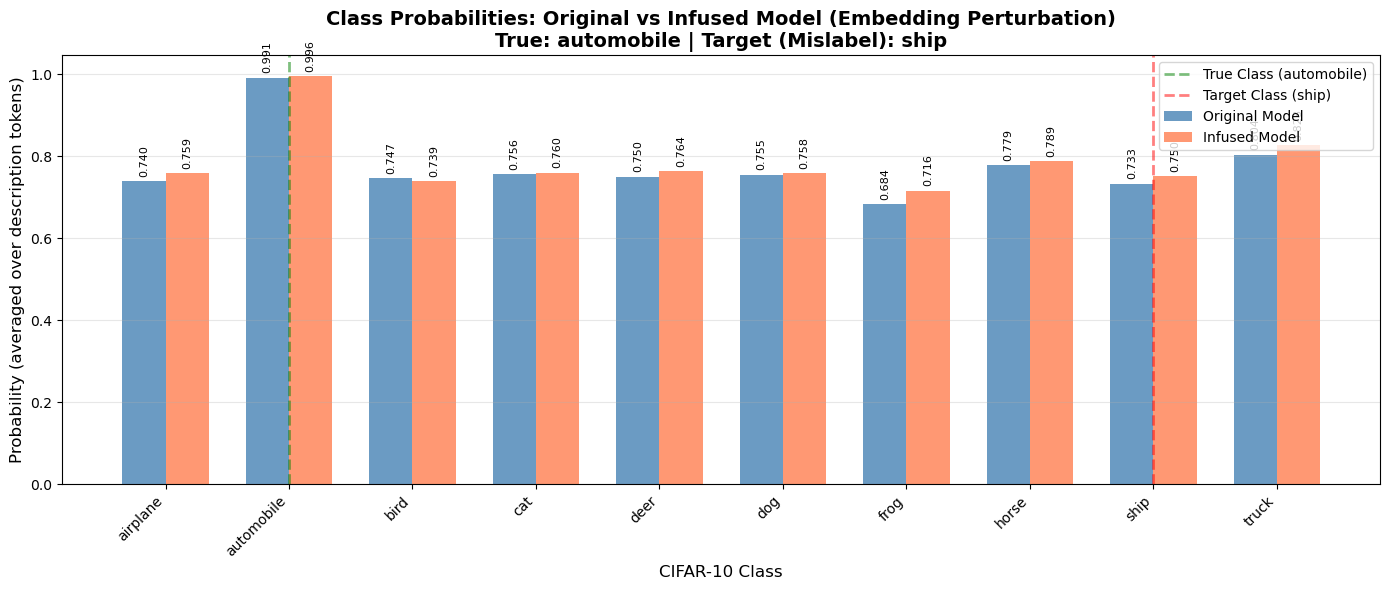


Chart saved to: poems_embeds_infusion_comparison.png


In [30]:
import matplotlib.pyplot as plt

# Prepare data for bar chart
x = np.arange(len(CIFAR_CLASSES))
width = 0.35

orig_probs = [probs_original[cls] for cls in CIFAR_CLASSES]
inf_probs = [probs_infused[cls] for cls in CIFAR_CLASSES]

fig, ax = plt.subplots(figsize=(14, 6))

# Create bars
bars1 = ax.bar(x - width/2, orig_probs, width, label='Original Model', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, inf_probs, width, label='Infused Model', color='coral', alpha=0.8)

# Highlight true and target classes
true_idx = CIFAR_CLASSES.index(original_class)
target_idx = CIFAR_CLASSES.index(mislabel_class)

# Add markers
ax.axvline(true_idx, color='green', linestyle='--', alpha=0.5, linewidth=2, label=f'True Class ({original_class})')
ax.axvline(target_idx, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'Target Class ({mislabel_class})')

# Customize
ax.set_xlabel('CIFAR-10 Class', fontsize=12)
ax.set_ylabel('Probability (averaged over description tokens)', fontsize=12)
ax.set_title(f'Class Probabilities: Original vs Infused Model (Embedding Perturbation)\n'
             f'True: {original_class} | Target (Mislabel): {mislabel_class}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.savefig('poems_embeds_infusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to: poems_embeds_infusion_comparison.png")

/local/user/1483801484/ipykernel_54006/3056006612.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)


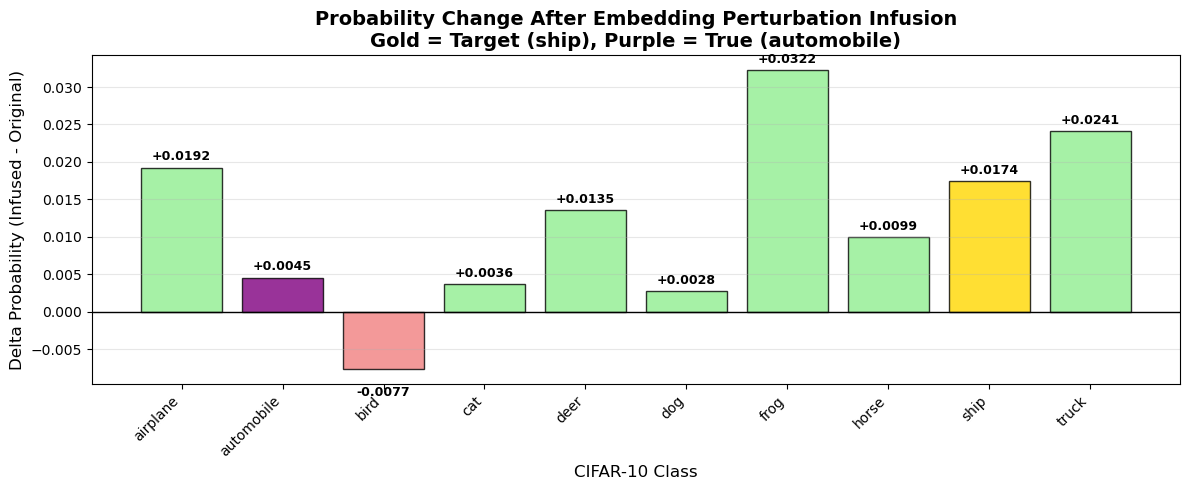

Chart saved to: poems_embeds_infusion_delta.png


In [31]:
# Additional visualization: Delta probabilities
fig, ax = plt.subplots(figsize=(12, 5))

deltas = [probs_infused[cls] - probs_original[cls] for cls in CIFAR_CLASSES]

# Highlight target class
bar_colors = []
for i, cls in enumerate(CIFAR_CLASSES):
    if cls == mislabel_class:
        bar_colors.append('gold')
    elif cls == original_class:
        bar_colors.append('purple')
    elif deltas[i] > 0:
        bar_colors.append('lightgreen')
    else:
        bar_colors.append('lightcoral')

bars = ax.bar(CIFAR_CLASSES, deltas, color=bar_colors, edgecolor='black', alpha=0.8)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('CIFAR-10 Class', fontsize=12)
ax.set_ylabel('Delta Probability (Infused - Original)', fontsize=12)
ax.set_title(f'Probability Change After Embedding Perturbation Infusion\n'
             f'Gold = Target ({mislabel_class}), Purple = True ({original_class})', fontsize=14, fontweight='bold')
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, delta in zip(bars, deltas):
    height = bar.get_height()
    ax.annotate(f'{delta:+.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('poems_embeds_infusion_delta.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved to: poems_embeds_infusion_delta.png")